# Forest Disturbance Use Case

This notebook walks through the forest disturbance subset, embedding analysis and outlines differnet starting points for downstream analyses.

In [56]:
%matplotlib inline
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from sklearn.decomposition import PCA

# For this tutorial we provide ready-to-use loading utilities so we can focus on
# analysis and modelling. For your custom datasets, existing geospatial data loaders
# can be a good starting point and adapted to the data specifics.
import s2tutorial as s2t

# We point to the data storage location and metadata files
ROOT = Path(os.environ.get('S2T_DATA_ROOT'))

meta = s2t.load_metadata(ROOT)
samples, labels, frames, classes = (
    meta['samples'], meta['labels'], meta['frames'], meta['classes']
)

## Data Exploration

In [17]:
# Build the per-sample summary table.
n_obs_per_sid = (
    frames.group_by('sample_id').len().rename({'len': 'n_obs'})
)
event_rows = (
    labels.filter(pl.col('is_event'))
    .select(
        'sample_id',
        pl.col('label').alias('event_label'),
        pl.col('start').alias('event_date'),
    )
)
event_names = pl.DataFrame(
    {'event_label': list(s2t.SHORT_NAMES.keys()),
     'event_type':  list(s2t.SHORT_NAMES.values())},
    schema={'event_label': pl.UInt16, 'event_type': pl.Utf8},
)

summary = (
    samples
    .join(n_obs_per_sid, on='sample_id', how='left')
    .join(event_rows,    on='sample_id', how='left')
    .join(event_names,   on='event_label', how='left')
    .select(
        'sample_id',
        pl.col('window_start').alias('ts_start'),
        pl.col('window_end').alias('ts_end'),
        'n_obs',
        'event_type',
        'event_date',
    )
    .sort('sample_id')
)

print(f'{len(summary)} samples\n')
with pl.Config(tbl_rows=len(summary), tbl_cols=10):
    print(summary)

200 samples

shape: (200, 6)
┌───────────┬────────────┬────────────┬───────┬────────────┬────────────┐
│ sample_id ┆ ts_start   ┆ ts_end     ┆ n_obs ┆ event_type ┆ event_date │
│ ---       ┆ ---        ┆ ---        ┆ ---   ┆ ---        ┆ ---        │
│ u16       ┆ date       ┆ date       ┆ u32   ┆ str        ┆ date       │
╞═══════════╪════════════╪════════════╪═══════╪════════════╪════════════╡
│ 0         ┆ 2016-11-03 ┆ 2024-12-31 ┆ 94    ┆ Wildfire   ┆ 2021-09-18 │
│ 1         ┆ 2016-05-01 ┆ 2024-10-16 ┆ 73    ┆ Clear-Cut  ┆ 2021-05-01 │
│ 2         ┆ 2016-03-16 ┆ 2025-01-01 ┆ 105   ┆ Clear-Cut  ┆ 2022-03-16 │
│ 3         ┆ 2016-11-03 ┆ 2024-12-31 ┆ 95    ┆ Wildfire   ┆ 2021-09-18 │
│ 4         ┆ 2015-08-19 ┆ 2024-11-19 ┆ 91    ┆ Clear-Cut  ┆ 2019-04-28 │
│ 5         ┆ 2016-11-03 ┆ 2024-12-31 ┆ 97    ┆ Wildfire   ┆ 2021-09-18 │
│ 6         ┆ 2016-11-15 ┆ 2024-12-30 ┆ 60    ┆ Wind       ┆ 2018-10-31 │
│ 7         ┆ 2016-12-31 ┆ 2024-12-31 ┆ 69    ┆ Wind       ┆ 2018-04-07 │
│ 8      

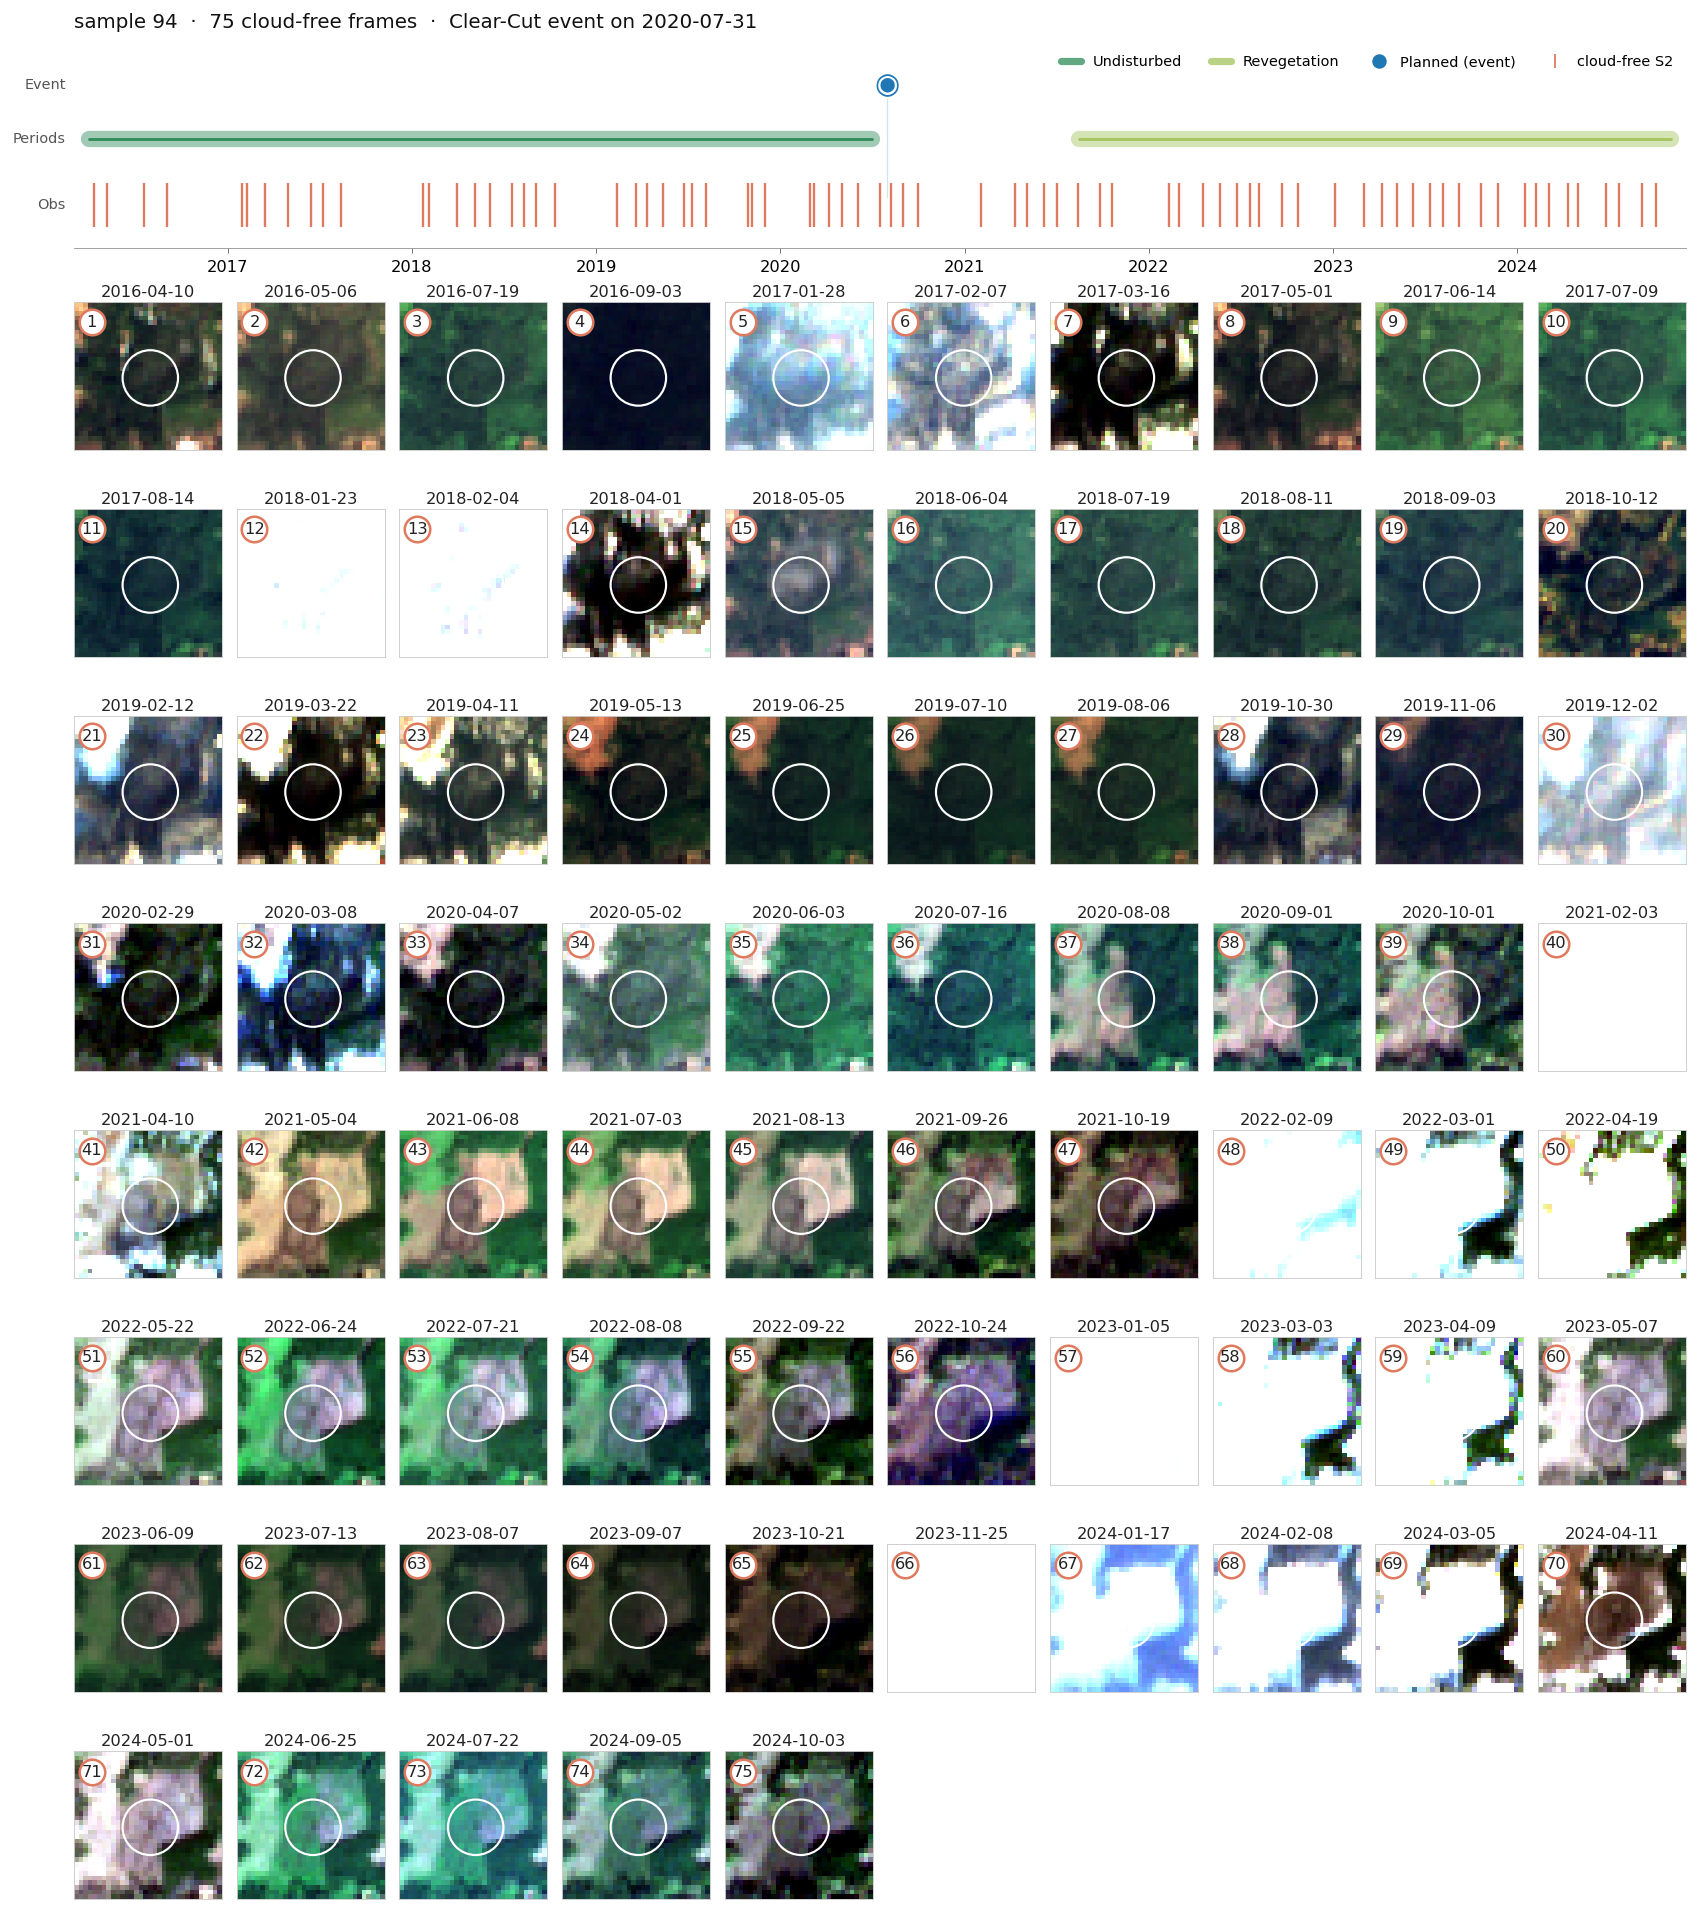

In [25]:
QUERY_SID = 94   # Pick a sample — anything in 0..99
ts = s2t.get_sample(ROOT, QUERY_SID, metadata=meta)
s2t.full_timeseries(ts, mode='rgb', ncols=10, panel_size=1.6, crop_size=32)
plt.show()

## TerraTorch Dataloader

In [ ]:
datamodule = s2t.ForestDisturbanceDataModule(
    root=ROOT,
    batch_size=8,
    num_workers=0,
    sample_mode="sequences", # Change to frames and explore how the return shape changes
    label_mode="grouped",
    sequence_length=10,
    sequence_stride=1,
    predict_split="all",
    sensor="s2_all",
)

datamodule.setup("predict")
batch = next(iter(datamodule.predict_dataloader()))
print("image:", batch["image"].shape)

image: torch.Size([8, 12, 10, 252, 252])


In [ ]:
# Explore what other keys are contained in batch? which represent the label and how?



## Embedding Generation

For simplicity we pre-generated embeddings, given the dataloader the workflow is similar to our previous embedding generation, see the `embedding_generation_forest.ipynb` notebook to follow how the emebddings were generated.

## Embedding Exploration

In [49]:
ROOT = Path(os.environ.get("S2T_DATA_ROOT", ".."))

# We work with both annotated patch embedding, and full dense embedding
EMBEDDING_ROOTS = {
    "embedding": Path(
        os.environ.get(
            "S2T_EMBEDDING_ROOT",
            ROOT / "embeddings" / "terramind_v1_small" / "layer_00",
        )
    ),
    "embedding_patch_center": Path(
        os.environ.get(
            "S2T_EMBEDDING_PATCH_CENTER_ROOT",
            ROOT / "embeddings_center_patch" / "terramind_v1_small" / "layer_00",
        )
    ),
}

In [ ]:

SPLIT_FILE = Path(os.environ.get("S2T_SPLIT_FILE", ROOT / "splits.parquet"))

required = [
    ROOT / "samples.parquet",
    ROOT / "labels.parquet",
    ROOT / "frames.parquet",
    ROOT / "classes.json",
    ROOT / "patches",
]
missing = [path for path in required if not path.exists()]
for name, root in EMBEDDING_ROOTS.items():
    if not root.is_dir():
        missing.append(root)
    elif not any(root.glob("*.zarr")):
        missing.append(f"no *.zarr stores in {root}")

if missing:
    raise RuntimeError(
        "Required data or embeddings are missing:"
        + "\n"
        + "\n".join(f"- {item}" for item in missing)
    )

print(f"Data root:    {ROOT}")
print(f"Split file:   {SPLIT_FILE}")
for name, root in EMBEDDING_ROOTS.items():
    print(f"{name:23s}: {root} ({len(list(root.glob('*.zarr')))} stores)")

In [51]:
def make_dm(source, **kwargs):
    return s2t.ForestDisturbanceEmbeddingDataModule(
        root=ROOT,
        embedding_root=EMBEDDING_ROOTS[source],
        split_file=SPLIT_FILE,
        num_workers=0,
        **kwargs,
    )

sequence_dms = {
    source: make_dm(
        source,
        sample_mode="sequences",
        sequence_length=8,
        sequence_stride=1,
        label_mode="grouped",
        batch_size=4,
    )
    for source in EMBEDDING_ROOTS
}
for dm in sequence_dms.values():
    dm.setup("fit")

print("classes:", sequence_dms["embedding"].train_dataset.classes)

classes: ('No Event', 'Planned', 'Wildfire', 'Wind')


In [63]:
# This snippet cherry-picks samples with an event in the middle of the sequence
dataset = sequence_dms["embedding"].train_dataset
labels_df = dataset.metadata["labels"]
frames_df = dataset.metadata["frames"]

event_groups = {211: 1, 212: 1, 213: 1, 242: 2, 243: 3}

examples = []
seen_ids = set()

for idx, (sample_id, start, stop, *_rest) in enumerate(dataset.index):

    # only keep one sequence per sample
    if sample_id in seen_ids:
        continue

    event = labels_df.filter(
        (pl.col("sample_id") == sample_id) & pl.col("is_event")
    )

    if event.is_empty():
        continue

    event_date = event[0, "start"]
    event_code = int(event[0, "label"])

    if event_code not in event_groups:
        continue

    dates = (
        frames_df
        .filter(pl.col("sample_id") == sample_id)
        .sort("date")["date"]
        .to_list()[start:stop]
    )

    # frame closest to the event
    event_idx = np.argmin([
        abs((date - event_date).days) for date in dates
    ])

    # skip events too close to the sequence borders
    if event_idx < 3 or event_idx >= len(dates) - 3:
        continue

    examples.append(
        (idx, dataset[idx], event_idx, event_code, event_date)
    )

    seen_ids.add(sample_id)

    if len(examples) == 5:
        break

Selected 5 event-centered sequences:

- idx   52 | sample  44 | Wildfire     | event code 242 | event date 2021-09-18 | closest frame t=4
- idx  111 | sample  57 | Wind         | event code 243 | event date 2020-02-15 | closest frame t=4
- idx  182 | sample 157 | Planned      | event code 211 | event date 2020-04-09 | closest frame t=4
- idx  276 | sample  64 | Wildfire     | event code 242 | event date 2021-09-18 | closest frame t=4
- idx  365 | sample  19 | Wildfire     | event code 242 | event date 2021-09-18 | closest frame t=4


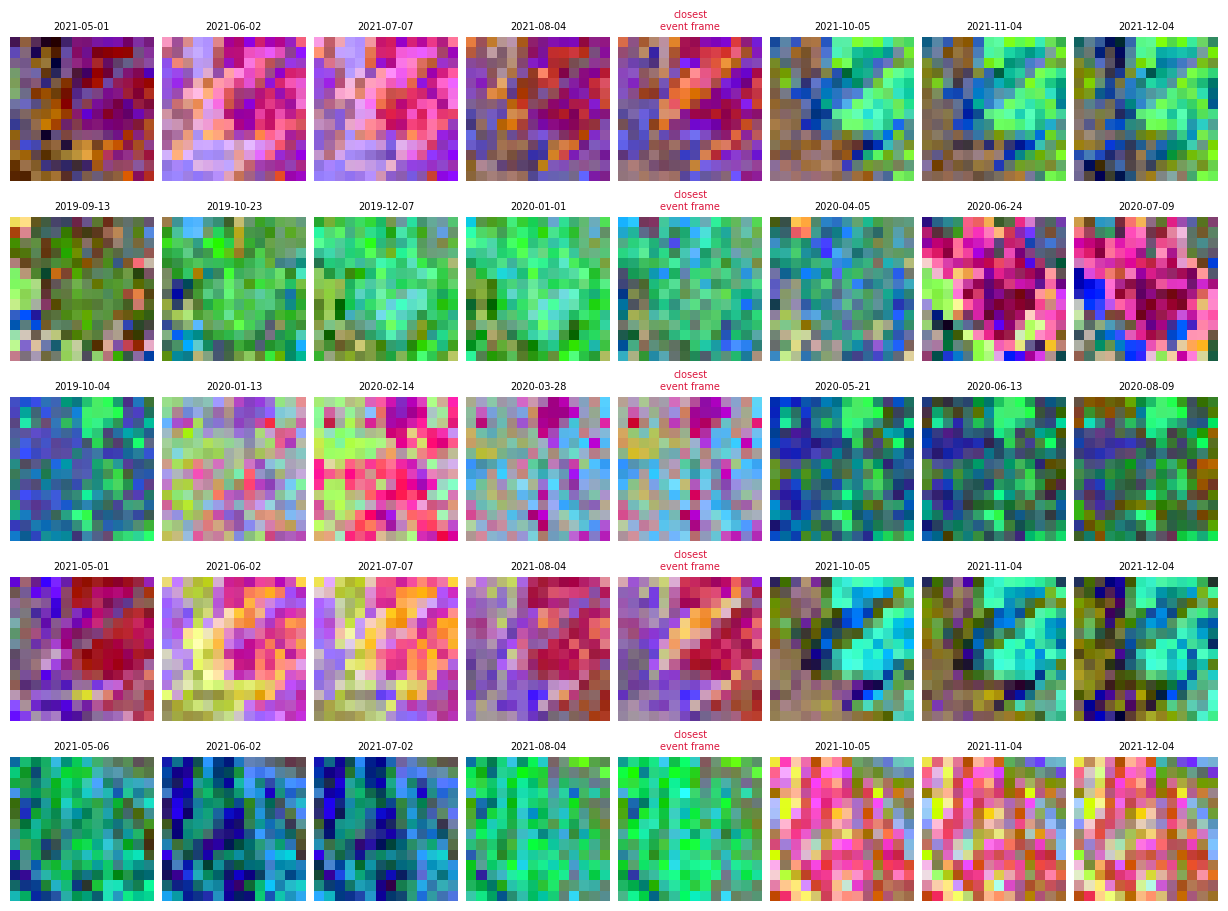

In [64]:
# Let's look at some examples

print(f"Selected {len(examples)} event-centered sequences:\n")

for idx, sample, event_idx, event_code, event_date in examples:
    label_name = dataset.classes[int(sample["label"])]
    sample_id = int(sample["sample_id"])

    print(
        f"- idx {idx:4d} | sample {sample_id:3d} | {label_name:<12s} "
        f"| event code {event_code} | event date {event_date} "
        f"| closest frame t={event_idx}"
    )

samples = [sample for _, sample, *_ in examples]

fig = dataset.plot_pca_timeseries(
    samples,
    pca_step=16,
    temporal_center=True,
)

axes = np.asarray(fig.axes).reshape(len(samples), -1)

for row, (_, _, event_idx, *_rest) in enumerate(examples):
    ax = axes[row, event_idx]
    ax.set_title("closest\nevent frame", color="crimson", fontsize=7)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("crimson")
        spine.set_linewidth(2)

plt.show()

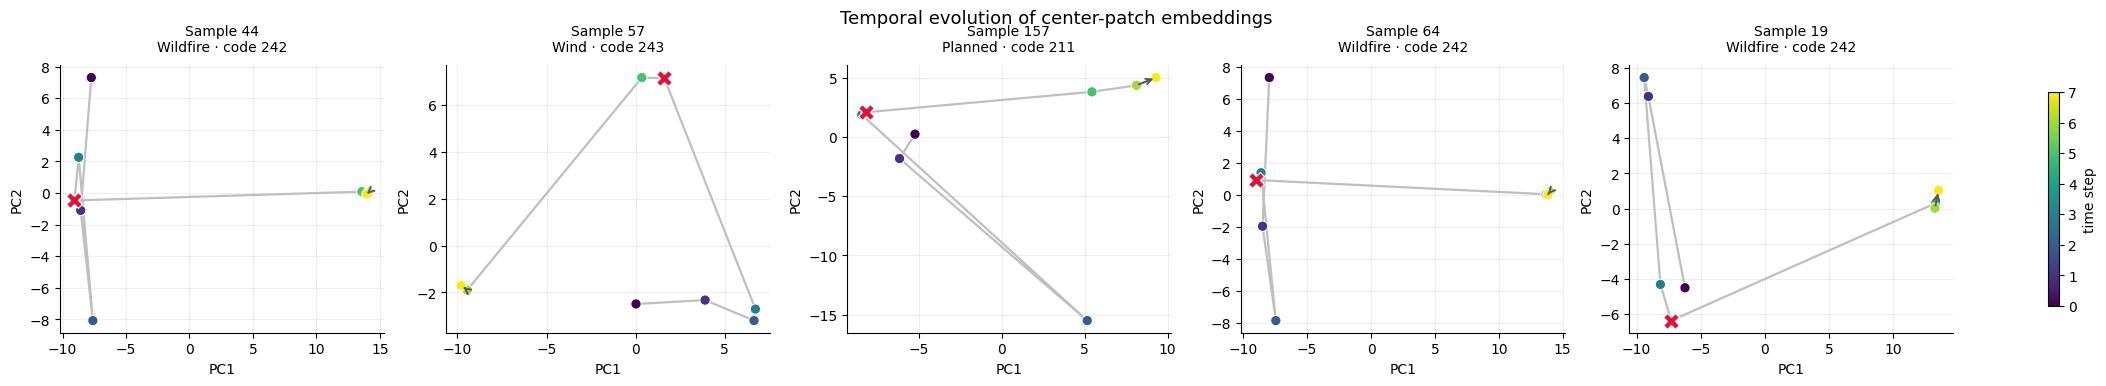

In [65]:
# PCA trajectory of temporal embedding evolution per sample.
# Each point is one observation in time; the red X marks the frame closest to the event date.

fig, axes = plt.subplots(
    1,
    len(examples),
    figsize=(4.2 * len(examples), 3.6),
    layout="compressed",
)

axes = np.atleast_1d(axes)

for ax, (idx, sample, event_idx, event_code, event_date) in zip(axes, examples):
    center_sample = sequence_dms["embedding_patch_center"].train_dataset[idx]
    xy = PCA(n_components=2).fit_transform(
        center_sample["embedding"]
    )

    steps = np.arange(len(xy))

    ax.plot(
        xy[:, 0],
        xy[:, 1],
        color="0.75",
        linewidth=1.6,
        zorder=1,
    )

    points = ax.scatter(
        xy[:, 0],
        xy[:, 1],
        c=steps,
        cmap="viridis",
        s=55,
        edgecolor="white",
        linewidth=0.7,
        zorder=2,
    )

    ax.scatter(
        xy[event_idx, 0],
        xy[event_idx, 1],
        color="crimson",
        marker="X",
        s=130,
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
        label="closest event frame",
    )

    ax.annotate(
        "",
        xy=xy[-1],
        xytext=xy[-2],
        arrowprops=dict(arrowstyle="->", color="0.35", lw=1.4),
        zorder=4,
    )

    ax.set_title(
        f"Sample {int(sample['sample_id'])}\n"
        f"{dataset.classes[int(sample['label'])]} · code {event_code}",
        fontsize=10,
        pad=10,
    )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.2)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.colorbar(points, ax=axes, label="time step", shrink=0.8)
fig.suptitle("Temporal evolution of center-patch embeddings", fontsize=13, y=1.03)

plt.show()

In [ ]:
# Check plots as above for negative (no event) samples, for that its best if you adapt the cherry pick function above that populates examples.


## Downstream 

For this we will use a different mode of the dataloader that directly returns per and post event mean averaged summary embeddings.

In [73]:
datamodule_task = s2t.ForestDisturbanceEmbeddingDataModule(
        root=ROOT,
        embedding_root=EMBEDDING_ROOTS["embedding_patch_center"],
        split_file=SPLIT_FILE,
        num_workers=0,
        sample_mode="event_centered",
        event_window_mode="mean",
        event_context_days=365,
        label_mode="grouped",
        batch_size=8,
    )
datamodule_task.setup("fit")

In [74]:
batch = next(iter(datamodule_task.train_dataloader()))
print("image:", batch["image"].shape)

image: torch.Size([8, 2, 384])


In [75]:
batch["label"]

tensor([2, 1, 2, 0, 1, 1, 2, 0])

In [80]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics.classification import MulticlassAccuracy

device = "cuda" if torch.cuda.is_available() else "cpu"

train_loader = datamodule_task.train_dataloader()
val_loader = datamodule_task.val_dataloader()

batch = next(iter(train_loader))

input_dim = batch["image"].shape[-1] * 3
num_classes = len(datamodule_task.train_dataset.classes)


models = {
    "linear": nn.Linear(input_dim, num_classes),
    "mlp": nn.Sequential(
        nn.Linear(input_dim, 128),
        nn.ReLU(),
        nn.Linear(128, num_classes),
    ),
}


def evaluate(model):
    model.eval()

    acc = MulticlassAccuracy(num_classes=num_classes).to(device)

    with torch.no_grad():
        for batch in val_loader:
            x = batch["image"].float()
            x = torch.cat([x[:, 0], x[:, 1], x[:, 1] - x[:, 0]], dim=1) 
            y = batch["label"].to(device)

            preds = model(x).argmax(dim=1)
            acc.update(preds, y)

    return acc.compute().item()


for name, model in models.items():
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # simple training loop
    for epoch in range(10):
        model.train()

        for batch in train_loader:
            x = batch["image"].float()
            x = torch.cat([x[:, 0], x[:, 1], x[:, 1] - x[:, 0]], dim=1) 
            y = batch["label"].to(device)

            loss = F.cross_entropy(model(x), y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    val_acc = evaluate(model)

    print(f"{name:7s} validation accuracy: {val_acc:.3f}")

linear  validation accuracy: 0.763
mlp     validation accuracy: 0.790
